# Coffee Quality
# Machine Learning - Assignment 1
# By : 
# Aryam
# Deem Ali Alnughmush - 421201996
# Renad 
# Rahaf 
# Fay

In [89]:
%pip install -q --upgrade pandas numpy scikit-learn matplotlib

import sys, platform, importlib
import pandas as pd, numpy as np
import sklearn

print("Python  :", sys.version.split()[0], "|", platform.platform())
print("pandas  :", pd.__version__)
print("numpy   :", np.__version__)
print("sklearn :", sklearn.__version__)

Note: you may need to restart the kernel to use updated packages.
Python  : 3.12.4 | Windows-11-10.0.26100-SP0
pandas  : 2.3.3
numpy   : 1.26.4
sklearn : 1.7.2


In [90]:
import os
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

In [91]:
DATA_PATH = Path(r"C:\Users\Deema\OneDrive\سطح المكتب\Coffee_quality-ML\merged_data_cleaned.csv")

In [92]:
df_raw = pd.read_csv(DATA_PATH)
print(df_raw.shape)
display(df_raw.head(3))
df_raw.info()

(1339, 44)


,Unnamed: 0,Species,Owner,Country.of.Origin,Farm.Name,Lot.Number,Mill,ICO.Number,Company,Altitude,Region,Producer,Number.of.Bags,Bag.Weight,In.Country.Partner,Harvest.Year,Grading.Date,Owner.1,Variety,Processing.Method,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean.Cup,Sweetness,Cupper.Points,Total.Cup.Points,Moisture,Category.One.Defects,Quakers,Color,Category.Two.Defects,Expiration,Certification.Body,Certification.Address,Certification.Contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
0,0,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,METAD PLC,300,60 kg,METAD Agricultural Development plc,2014,"April 4th, 2015",metad plc,NaN,Washed / Wet,8.67,8.83,8.67,8.75,8.50,8.42,10.0,10.0,10.0,8.75,90.58,0.12,0,0.0,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
1,1,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,METAD PLC,300,60 kg,METAD Agricultural Development plc,2014,"April 4th, 2015",metad plc,Other,Washed / Wet,8.75,8.67,8.50,8.58,8.42,8.42,10.0,10.0,10.0,8.58,89.92,0.12,0,0.0,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,2,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,NaN,NaN,5,1,Specialty Coffee Association,NaN,"May 31st, 2010",Grounds for Health Admin,Bourbon,NaN,8.42,8.50,8.42,8.42,8.33,8.42,10.0,10.0,10.0,9.25,89.75,0.00,0,0.0,NaN,0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1339 entries, 0 to 1338
Data columns (total 44 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             1339 non-null   int64  
 1   Species                1339 non-null   object 
 2   Owner                  1332 non-null   object 
 3   Country.of.Origin      1338 non-null   object 
 4   Farm.Name              980 non-null    object 
 5   Lot.Number             276 non-null    object 
 6   Mill                   1021 non-null   object 
 7   ICO.Number             1180 non-null   object 
 8   Company                1130 non-null   object 
 9   Altitude               1113 non-null   object 
 10  Region                 1280 non-null   object 
 11  Producer               1107 non-null   object 
 12  Number.of.Bags         1339 non-null   int64  
 13  Bag.Weight             1339 non-null   object 
 14  In.Country.Partner     1339 non-null   object 
 15  Harv

In [93]:
# Choose useful columns.
desired_cols = [
    "Species", "Country.of.Origin", "Region", "Variety", "Processing.Method",
    "Aroma", "Flavor", "Aftertaste", "Acidity", "Body", "Balance",
    "Uniformity", "Clean.Cup", "Sweetness", "Cupper.Points",
    "Moisture", "Category.One.Defects", "Category.Two.Defects",
    "Quakers", "altitude_mean_meters", "Total.Cup.Points"
]

missing = [c for c in desired_cols if c not in df_raw.columns]
if missing:
    print(" Missing columns (will be skipped):", missing)

use_cols = [c for c in desired_cols if c in df_raw.columns]
df = df_raw[use_cols].copy()
print("Using columns:", use_cols)
print(df.shape)


Using columns: ['Species', 'Country.of.Origin', 'Region', 'Variety', 'Processing.Method', 'Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity', 'Clean.Cup', 'Sweetness', 'Cupper.Points', 'Moisture', 'Category.One.Defects', 'Category.Two.Defects', 'Quakers', 'altitude_mean_meters', 'Total.Cup.Points']
(1339, 21)


In [94]:
# Check missing values

na_counts = df.isna().sum().sort_values(ascending=False)
display(na_counts.to_frame("missing_count").T)

# Must have the target
if "Total.Cup.Points" not in df.columns:
    raise ValueError("Target column 'Total.Cup.Points' is not present in data.")

# Drop rows with missing target
before = len(df)
df = df.dropna(subset=["Total.Cup.Points"])
print(f"Dropped {before - len(df)} rows with missing target.")

# Separate numeric vs categorical columns
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

# Keep target out of feature lists
if "Total.Cup.Points" in num_cols:
    num_cols.remove("Total.Cup.Points")
if "Total.Cup.Points" in cat_cols:
    cat_cols.remove("Total.Cup.Points")

print("Numeric cols:", num_cols)
print("Categorical cols:", cat_cols)

# Simple imputation: numeric -> median, categorical -> "Unknown"
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna("Unknown")

# Sanity check
display(df.isna().sum().to_frame("missing_after_impute").T)


,altitude_mean_meters,Variety,Processing.Method,Region,Quakers,Country.of.Origin,Species,Sweetness,Category.Two.Defects,Category.One.Defects,Moisture,Cupper.Points,Balance,Clean.Cup,Uniformity,Body,Acidity,Aftertaste,Flavor,Aroma,Total.Cup.Points
missing_count,230,226,170,59,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Dropped 0 rows with missing target.
Numeric cols: ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Uniformity', 'Clean.Cup', 'Sweetness', 'Cupper.Points', 'Moisture', 'Category.One.Defects', 'Category.Two.Defects', 'Quakers', 'altitude_mean_meters']
Categorical cols: ['Species', 'Country.of.Origin', 'Region', 'Variety', 'Processing.Method']


,Species,Country.of.Origin,Region,Variety,Processing.Method,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean.Cup,Sweetness,Cupper.Points,Moisture,Category.One.Defects,Category.Two.Defects,Quakers,altitude_mean_meters,Total.Cup.Points
missing_after_impute,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [95]:
# Define features and target
TARGET = "Total.Cup.Points"
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(float)

# EN: Train and Test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

len(X_train), len(X_test), y_train.mean(), y_test.mean()


(1071, 268, 82.16631185807655, 81.78429104477611)

In [96]:
# Build preprocessing pipeline:
# - OneHotEncoder for categorical (drop=None to keep all categories)
# - StandardScaler for numeric

categorical_transformer = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
numeric_transformer     = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, cat_cols),
        ("num", numeric_transformer,     num_cols),
    ],
    remainder="drop"
)

# Fit on train only, then transform train & test
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

X_train_prep.shape, X_test_prep.shape


((1071, 409), (268, 409))

In [97]:
# Build feature names after OneHot for readability and exporting
cat_feature_names = []
if cat_cols:
    cat_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(cat_cols).tolist()
num_feature_names = num_cols
all_feature_names = cat_feature_names + num_feature_names

len(all_feature_names), all_feature_names[:10]


(409,
 ['Species_Arabica',
  'Species_Robusta',
  'Country.of.Origin_Brazil',
  'Country.of.Origin_Burundi',
  'Country.of.Origin_China',
  'Country.of.Origin_Colombia',
  'Country.of.Origin_Costa Rica',
  'Country.of.Origin_Cote d?Ivoire',
  'Country.of.Origin_Ecuador',
  'Country.of.Origin_El Salvador'])

In [98]:
# Save preprocessed matrices and also a human-readable CSV

out_dir = Path("artifacts")
out_dir.mkdir(exist_ok=True)

# Numpy .npz (compact)
np.savez_compressed(
    out_dir / "coffee_preprocessed_split.npz",
    X_train=X_train_prep,
    X_test=X_test_prep,
    y_train=y_train.values,
    y_test=y_test.values,
    feature_names=np.array(all_feature_names, dtype=object)
)

# CSV (merged preprocessed) — optional, larger size
train_df = pd.DataFrame(X_train_prep, columns=all_feature_names)
train_df[TARGET] = y_train.values
test_df = pd.DataFrame(X_test_prep, columns=all_feature_names)
test_df[TARGET] = y_test.values

train_df.to_csv(out_dir / "train_preprocessed.csv", index=False)
test_df.to_csv(out_dir / "test_preprocessed.csv", index=False)

print("Saved:")
print(" -", (out_dir / "coffee_preprocessed_split.npz").resolve())
print(" -", (out_dir / "train_preprocessed.csv").resolve())
print(" -", (out_dir / "test_preprocessed.csv").resolve())


Saved:
 - C:\Users\Deema\OneDrive\سطح المكتب\Coffee_quality-ML\artifacts\coffee_preprocessed_split.npz
 - C:\Users\Deema\OneDrive\سطح المكتب\Coffee_quality-ML\artifacts\train_preprocessed.csv
 - C:\Users\Deema\OneDrive\سطح المكتب\Coffee_quality-ML\artifacts\test_preprocessed.csv


In [99]:
# Quick checks — distributions and basic correlations 
print("Train rows/cols:", train_df.shape)
display(train_df.describe().T.head(10))

# Target sanity
print("Target (train) mean/std:", train_df["Total.Cup.Points"].mean(), train_df["Total.Cup.Points"].std())
print("Target (test)  mean/std:", test_df["Total.Cup.Points"].mean(),  test_df["Total.Cup.Points"].std())


Train rows/cols: (1071, 410)


,count,mean,std,min,25%,50%,75%,max
Species_Arabica,1071.0,0.982260,0.132068,0.0,1.0,1.0,1.0,1.0
Species_Robusta,1071.0,0.017740,0.132068,0.0,0.0,0.0,0.0,1.0
Country.of.Origin_Brazil,1071.0,0.097106,0.296240,0.0,0.0,0.0,0.0,1.0
Country.of.Origin_Burundi,1071.0,0.001867,0.043193,0.0,0.0,0.0,0.0,1.0
Country.of.Origin_China,1071.0,0.010271,0.100870,0.0,0.0,0.0,0.0,1.0
Country.of.Origin_Colombia,1071.0,0.141923,0.349135,0.0,0.0,0.0,0.0,1.0
Country.of.Origin_Costa Rica,1071.0,0.038282,0.191966,0.0,0.0,0.0,0.0,1.0
Country.of.Origin_Cote d?Ivoire,1071.0,0.000934,0.030557,0.0,0.0,0.0,0.0,1.0
Country.of.Origin_Ecuador,1071.0,0.000934,0.030557,0.0,0.0,0.0,0.0,1.0
Country.of.Origin_El Salvador,1071.0,0.015873,0.125043,0.0,0.0,0.0,0.0,1.0


Target (train) mean/std: 82.16631185807655 2.7049391189513057
Target (test)  mean/std: 81.78429104477611 5.654119894390657


In [100]:
# Define models 
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor

model_linear  = LinearRegression()
model_ridge   = RidgeCV(alphas=[0.1, 1.0, 3.0, 10.0], cv=5)
model_rf      = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)

In [101]:
# Train Linear Regression
model_linear.fit(X_train_prep, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [102]:
# Predict with Linear Regression
y_pred_linear = model_linear.predict(X_test_prep)
len(y_pred_linear), y_pred_linear[:5]


(268, array([83.43708843, 81.67406082, 83.50552659, 83.50695162, 83.91345962]))

In [103]:
# Evaluate Linear Regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lin_mae  = mean_absolute_error(y_test, y_pred_linear)
lin_rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
lin_r2   = r2_score(y_test, y_pred_linear)
{"MAE": lin_mae, "RMSE": lin_rmse, "R2": lin_r2}


{'MAE': 0.009722256919595206,
 'RMSE': 0.032867837873712294,
 'R2': 0.9999660815671545}

In [104]:
# Train RidgeCV
model_ridge.fit(X_train_prep, y_train)


,alphas,"[0.1, 1.0, ...]"
,fit_intercept,True
,scoring,None
,cv,5
,gcv_mode,None
,store_cv_results,False
,alpha_per_target,False


In [105]:
# Predict with RidgeCV
y_pred_ridge = model_ridge.predict(X_test_prep)
len(y_pred_ridge), y_pred_ridge[:5]


(268, array([83.43145383, 81.67463504, 83.50520123, 83.50426765, 83.91071414]))

In [106]:
# Evaluate RidgeCV
ridge_mae  = mean_absolute_error(y_test, y_pred_ridge)
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_r2   = r2_score(y_test, y_pred_ridge)
{"MAE": ridge_mae, "RMSE": ridge_rmse, "R2": ridge_r2}


{'MAE': 0.009467313915649811,
 'RMSE': 0.032133008461419234,
 'R2': 0.9999675812487038}

In [107]:
# Train RandomForest
model_rf.fit(X_train_prep, y_train)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [108]:
# Predict with RandomForest
y_pred_rf = model_rf.predict(X_test_prep)
len(y_pred_rf), y_pred_rf[:5]


(268, array([82.55056667, 81.9018    , 83.51706667, 82.76483333, 83.76276667]))

In [109]:
# Evaluate RandomForest
rf_mae  = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2   = r2_score(y_test, y_pred_rf)
{"MAE": rf_mae, "RMSE": rf_rmse, "R2": rf_r2}


{'MAE': 0.5735374378109354,
 'RMSE': 4.014954523833816,
 'R2': 0.4938785227617649}

In [110]:
results_df = pd.DataFrame({
    "Linear":       {"TEST_MAE": lin_mae,   "TEST_RMSE": lin_rmse,   "TEST_R2": lin_r2},
    "RidgeCV":      {"TEST_MAE": ridge_mae, "TEST_RMSE": ridge_rmse, "TEST_R2": ridge_r2},
    "RandomForest": {"TEST_MAE": rf_mae,    "TEST_RMSE": rf_rmse,    "TEST_R2": rf_r2},
}).T.sort_values("TEST_R2", ascending=False)



In [111]:
best_name = results_df["TEST_R2"].idxmax()
best_name

'RidgeCV'

In [112]:
pred_map = {
    "Linear": y_pred_linear,
    "RidgeCV": y_pred_ridge,
    "RandomForest": y_pred_rf
}
y_pred_best = pred_map[best_name]
len(y_pred_best), best_name


(268, 'RidgeCV')

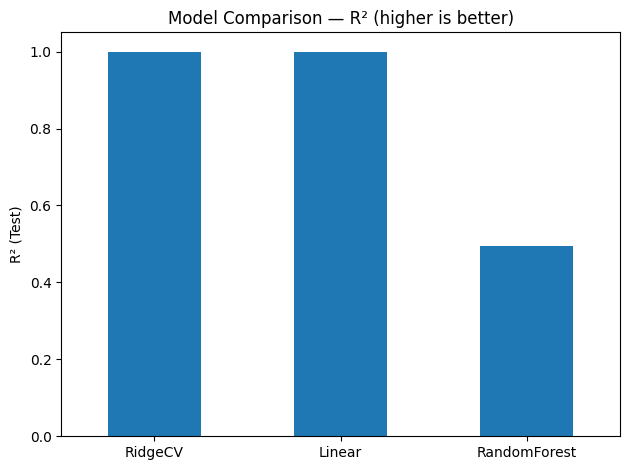

In [113]:
import matplotlib.pyplot as plt

plt.figure()
results_df["TEST_R2"].plot(kind="bar")
plt.ylabel("R² (Test)")
plt.title("Model Comparison — R² (higher is better)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("artifacts/compare_r2_3models.png", dpi=150)
plt.show()


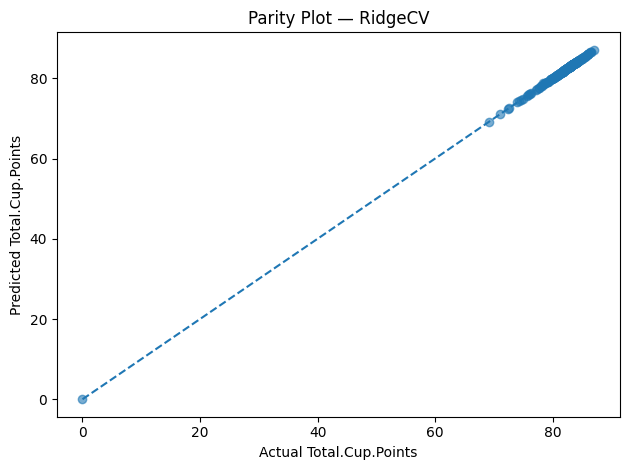

In [114]:
plt.figure()
plt.scatter(y_test, y_pred_best, alpha=0.6)
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Actual Total.Cup.Points")
plt.ylabel("Predicted Total.Cup.Points")
plt.title(f"Parity Plot — {best_name}")
plt.tight_layout()
plt.savefig(f"artifacts/parity_{best_name}_3models.png", dpi=150)
plt.show()


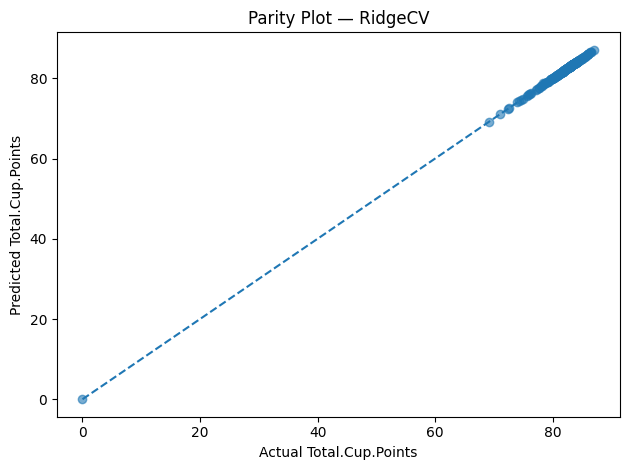

In [115]:
plt.figure()
plt.scatter(y_test, y_pred_best, alpha=0.6)
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Actual Total.Cup.Points")
plt.ylabel("Predicted Total.Cup.Points")
plt.title(f"Parity Plot — {best_name}")
plt.tight_layout()
plt.savefig(f"artifacts/parity_{best_name}_3models.png", dpi=150)
plt.show()


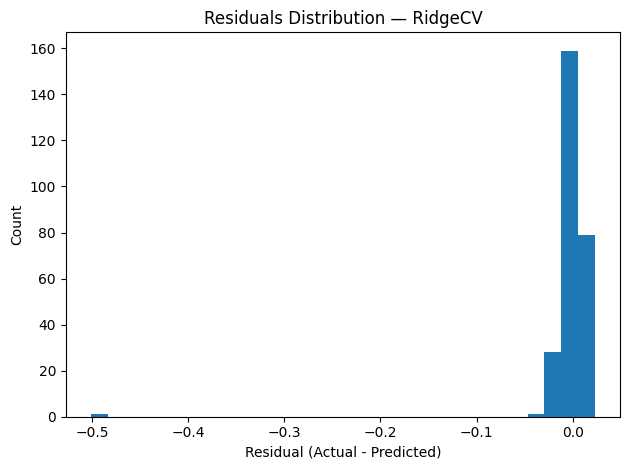

In [116]:
residuals = y_test - y_pred_best

plt.figure()
plt.hist(residuals, bins=30)
plt.title(f"Residuals Distribution — {best_name}")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(f"artifacts/residuals_{best_name}_3models.png", dpi=150)
plt.show()


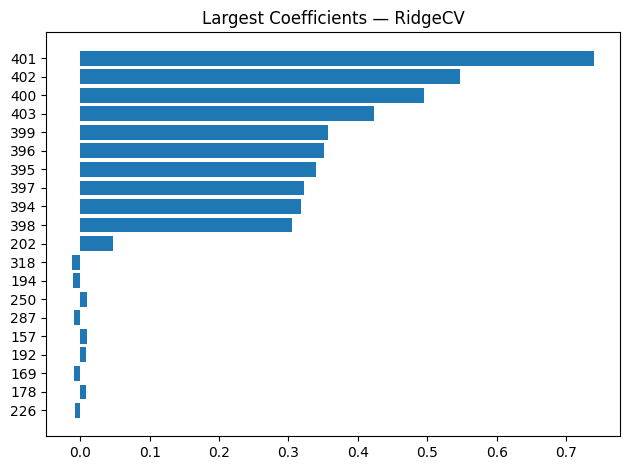

In [117]:
feat_names = feature_names if 'feature_names' in globals() and feature_names is not None else np.arange(X_test_prep.shape[1])

if best_name == "RandomForest" and hasattr(model_rf, "feature_importances_"):
    vals = model_rf.feature_importances_
    fi = pd.DataFrame({"feature": feat_names, "importance": vals}).sort_values("importance", ascending=False).head(20)

    plt.figure()
    plt.barh(fi["feature"].astype(str), fi["importance"])
    plt.gca().invert_yaxis()
    plt.title("Top Features — RandomForest")
    plt.tight_layout()
    plt.savefig("artifacts/top_features_RandomForest_3models.png", dpi=150)
    plt.show()
    fi

elif best_name in ["Linear", "RidgeCV"] and hasattr(model_linear if best_name=="Linear" else model_ridge, "coef_"):
    mdl = model_linear if best_name=="Linear" else model_ridge
    coefs = mdl.coef_.ravel() if getattr(mdl.coef_, "ndim", 1) > 1 else mdl.coef_
    cd = pd.DataFrame({"feature": feat_names, "coef": coefs})
    cd = cd.reindex(cd["coef"].abs().sort_values(ascending=False).index).head(20)

    plt.figure()
    plt.barh(cd["feature"].astype(str), cd["coef"])
    plt.gca().invert_yaxis()
    plt.title(f"Largest Coefficients — {best_name}")
    plt.tight_layout()
    plt.savefig(f"artifacts/top_coeffs_{best_name}_3models.png", dpi=150)
    plt.show()
    cd
else:
    print("No importances/coefficients available to display.")
